<a href="https://colab.research.google.com/github/kfartem434-png/MN_Kapusta/blob/main/%D0%9B%D0%912_1_%D0%9A%D0%B0%D0%BF%D1%83%D1%81%D1%82%D0%B0_3_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Капуста Артем, група 3-12

# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [188]:
import numpy as np
import pandas as pd
import requests

In [189]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url,headers={"User-Agent": "Chrome-Artem"}).text

tables = pd.read_html(html)
print(len(tables))
df = tables[2]

8


/tmp/ipykernel_1726/977640038.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


In [190]:
df.head()

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [191]:
print(df.shape)
print(df.columns)

(222, 4)
Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [192]:
df.columns = (
    df.columns
    .str.replace(r"(?:\s*\[\d+\])+","",regex=True)
    .str.replace("Country/Territory","Country",regex=False)
)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [193]:
df.drop(df[df.iloc[:,0] == "World"].index,inplace=True)

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [194]:
df["IMF (2026)"] = pd.to_numeric(df["IMF (2026)"],errors="coerce")
df["World Bank (2025)"] = pd.to_numeric(df["World Bank (2025)"],errors="coerce")
df["United Nations (2024)"] = pd.to_numeric(df["United Nations (2024)"],errors="coerce")

In [195]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [196]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [197]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [198]:
part = df.iloc[:,1:]

row_filled = part.apply(lambda x: x.fillna(x.mean()),axis=1)
col_means = part.mean()

df.iloc[:,1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [199]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [200]:
duplicates = df.duplicated()
duplicates.sum()

np.int64(0)

In [201]:
df.drop(duplicates.loc[duplicates].index,inplace=True)

7.	Вивести описову статистику датасету describe()

In [202]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.967683e+05,5.586715e+05,5.245465e+05
std,2.673702e+06,2.527984e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [227]:
df["IMF_WB_Diff"] = abs(df["IMF (2026)"] - df["World Bank (2025)"])

top_differences = df["IMF_WB_Diff"].sort_values(ascending=False)

df.loc[top_differences.iloc[:5].index,["Country","IMF_WB_Diff"]]

,Country,IMF_WB_Diff
1,United States,1614220.0
2,China[n 1],1353554.0
3,Germany,401935.0
10,Brazil,355992.0
12,Australia,325444.0


Найбільші різниці: США, Китай, Німеччина, Бразилія, Австралія.

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [204]:
corr = df.iloc[:,1:4].corr()
corr

,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.000000,0.999877,0.999804
World Bank (2025),0.999877,1.000000,0.999846
United Nations (2024),0.999804,0.999846,1.000000


In [205]:
corr_IMF = corr.loc["IMF (2026)",["World Bank (2025)","United Nations (2024)"]]
corr_WB = corr.loc["World Bank (2025)",["IMF (2026)","United Nations (2024)"]]
corr_UN = corr.loc["United Nations (2024)",["IMF (2026)","World Bank (2025)"]]
top_correlation = max(
  (corr_IMF.name,corr_IMF.idxmax(),corr_IMF.max()),
  (corr_WB.name,corr_WB.idxmax(),corr_WB.max()),
  (corr_UN.name,corr_UN.idxmax(),corr_UN.max()),
  key = lambda x: x[2]
)
print("Найбільшу кореляцію має пара змінних '%s' та '%s': %f" % top_correlation)

Найбільшу кореляцію має пара змінних 'IMF (2026)' та 'World Bank (2025)': 0.999877


Обчислити середнє значення за стовпцями

In [206]:
mean_IMF = df["IMF (2026)"].mean()
print(mean_IMF)

596768.2683972374


In [207]:
mean_WB = df["World Bank (2025)"].mean()
print(mean_WB)

558671.5364180411


In [208]:
mean_UN = df["United Nations (2024)"].mean()
print(mean_UN)

524546.5369247844


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [209]:
country_std = df.iloc[:,1:4].std(axis=1)
country_std.index = df["Country"]
country_std

,0
Country,
United States,1.543508e+06
China[n 1],1.068002e+06
Germany,3.964771e+05
Japan,2.217380e+05
United Kingdom,2.898838e+05
...,...
Palau,3.351119e+01
Marshall Islands,3.056687e+01
Nauru,1.001665e+01


In [213]:
print(f"Країна з найбільшою варіативністю: {country_std.idxmax()}, варіативність: {country_std.max()}")

Країна з найбільшою варіативністю: United States, варіативність: 1543508.4140144275


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [218]:
max_IMF = df["IMF (2026)"].max()
max_WB = df["World Bank (2025)"].max()
max_UN = df["United Nations (2024)"].max()

min_IMF = df["IMF (2026)"].min()
min_WB = df["World Bank (2025)"].min()
min_UN = df["United Nations (2024)"].min()

print(f"Максимальне IMF: {max_IMF}, Мінімальне IMF: {min_IMF}")
print(f"Максимальне WB: {max_WB}, Мінімальне WB: {min_WB}")
print(f"Максимальне UN: {max_UN}, Мінімальне UN: {min_UN}")

Максимальне IMF: 32383920.0, Мінімальне IMF: 65.0
Максимальне WB: 30769700.0, Мінімальне WB: 57.0
Максимальне UN: 29298000.0, Мінімальне UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

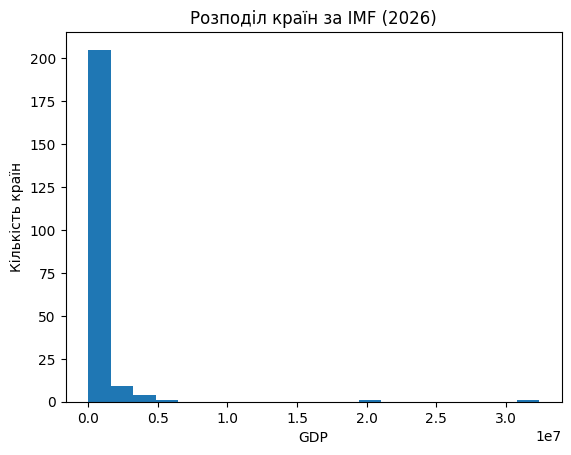

In [225]:
import matplotlib.pyplot as plt

df["IMF (2026)"].plot(kind="hist",bins=20,title="Розподіл країн за IMF (2026)")
plt.xlabel("GDP")
plt.ylabel("Кількість країн")
plt.show()

Розподіл має вигляд різкого зниження кількості країн. Можна побачити, що більщість країн (більш ніж 200) майють GDP у районі `0` - `0.33*10^7` мільйонів доларів; Меньш ніж 25 країн мають GDP від` 0.33*10^7`  до `0.88*10^7`  мільйонів доларів. Виділяються дві країни з високим рівнем GDP -- `2*10^7` мільйонів та `3.2*10^7` мільйонів доларів.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [226]:
df["IMF_Share"] = df["IMF (2026)"]/df["IMF (2026)"].sum()
df["WB_Share"] = df["World Bank (2025)"]/df["World Bank (2025)"].sum()
df["UN_Share"] = df["United Nations (2024)"]/df["United Nations (2024)"].sum()

df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,0.245545,0.249215,0.252733
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,0.158103,0.157922,0.161689
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,0.041345,0.040909,0.040198
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,0.033205,0.035922,0.034731
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,0.032337,0.032418,0.031795
6,India,4153191.0,3956067.0,3952244.0,197124.0,0.031491,0.032042,0.034093
7,France,3596094.0,3366316.0,3160443.0,229778.0,0.027267,0.027265,0.027263
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,0.020762,0.020666,0.020538
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,0.020142,0.020745,0.018748
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,0.019986,0.018466,0.018856


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

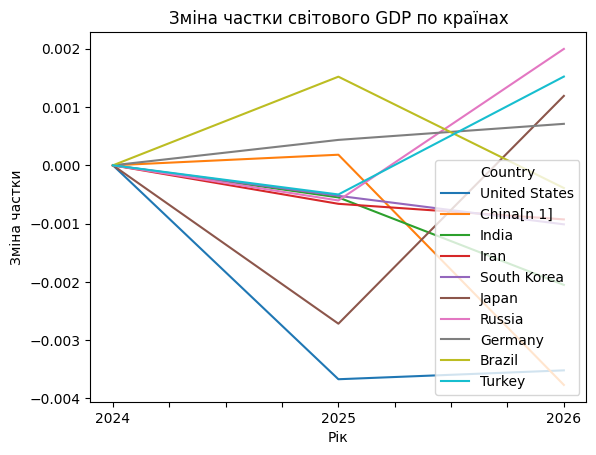

In [430]:
df["WB_UN_Diff"] = df["WB_Share"] - df["UN_Share"]
df["IMF_WB_Diff"] = df["IMF_Share"] - df["WB_Share"]
graph_frame = pd.DataFrame(
    data=(np.zeros(len(df)),df["IMF_WB_Diff"],df["WB_UN_Diff"]),
    index=("2024","2025","2026"),
    columns=df["Country"],
)
graph_frame.iloc[:,:10].plot(kind="line",title="Зміна частки світового GDP по країнах")
plt.xlabel("Рік")
plt.ylabel("Зміна частки")
plt.show()

Стабільне зростання чатски GDP показуює Німеччина, зпадання -- США, Індія, Піденна Корея.